# High-Level Synthesis with `synthesize()`

PowerGridSynth provides a single high-level function, `synthesize()`, that runs the **entire CLC pipeline** — topology generation, bus-type assignment, generation/load allocation, dispatch, transmission-line parameterization, and export — in one call.

Two operation modes are supported:

| Mode | Description |
|------|-------------|
| **Mode I – Reference-based** | Load an existing pandapower network (e.g. IEEE 118-bus), extract its topological parameters, and generate a structurally similar synthetic clone. |
| **Mode II – Fully synthetic** | Build a grid entirely from user-specified voltage-level specs (node counts, average degrees, diameters, degree distributions) and inter-level connection parameters. |

For **step-by-step control** over each pipeline stage, see the other example notebooks:
[TopologyGeneration](TopologyGeneration.ipynb),
[BusTypeAssignment](BusTypeAssignment.ipynb),
[GenLoadSettings](GenLoadSettings.ipynb), and
[ieee_test](ieee_test.ipynb).

In [1]:
from powergrid_synth import synthesize

## Mode I — Reference-Based Synthesis

Generate a synthetic grid whose topology statistically mirrors an existing pandapower case.
The function extracts degree distributions, diameters, and voltage-level structure from the
reference grid, then synthesises a new grid with the same statistical profile.

Key parameters:
- `reference_case`: name of any built-in pandapower network (e.g. `"case118"`, `"case300"`, `"case_ieee30"`)
- `seed`: random seed for reproducibility
- `export_formats`: list of output formats — `"json"`, `"cgmes"`, `"matpower"`, `"psse"`, `"xiidm"`, `"excel"`, etc.

In [2]:
grid_ref = synthesize(
    mode="reference",
    reference_case="case118",
    seed=42,
    output_dir="output/ref_synthesis",
    output_name="ieee118_clone",
    export_formats=["json", "cgmes", "matpower"],
)

print(f"\nSynthesised grid: {grid_ref.number_of_nodes()} nodes, {grid_ref.number_of_edges()} edges")

Extracting topology parameters...
[1] Loaded reference grid: 118 nodes, 179 edges.
--- Starting Generation for 3 Voltage Levels ---
Generating Level 0...
  -> Level 0 Complete. Nodes: 14, Edges: 9
Generating Level 1...
  -> Level 1 Complete. Nodes: 2, Edges: 0
Generating Level 2...
  -> Level 2 Complete. Nodes: 116, Edges: 151
Generating Transformer Connections...
  -> Connecting Level 0 <-> Level 1
  -> Connecting Level 0 <-> Level 2
  -> Connecting Level 1 <-> Level 2
Filtering for Largest Connected Component (LCC)...
  -> Kept 123 nodes (removed 9 isolated nodes)
[2] Topology generated: 123 nodes, 171 edges.
Starting Bus Type Allocation (N=123, M=171)...
  Target Entropy Score (W*): 2.6046, Std Dev: 0.0422
  Iter 0: Best Error = 0.000219
  Converged at iteration 9. Error: 0.000026 < Criteria: 0.000042
[3] Bus types assigned: Gen: 28 (23%), Load: 68 (55%), Conn: 27 (22%)
Allocating Capacity for 28 generators.
Total System Capacity Target: 11168.29 MW using Reference System 1
[4] Gene

### Inspect the synthetic grid

In [3]:
import collections

bus_types = [data.get("bus_type", "?") for _, data in grid_ref.nodes(data=True)]
counter = collections.Counter(bus_types)
print("Bus-type breakdown:")
for bt, cnt in sorted(counter.items()):
    print(f"  {bt:12s}: {cnt:4d}  ({cnt/grid_ref.number_of_nodes()*100:.1f}%)")

Bus-type breakdown:
  Conn        :   27  (22.0%)
  Gen         :   28  (22.8%)
  Load        :   68  (55.3%)


Calculating layout 'kamada_kawai'...


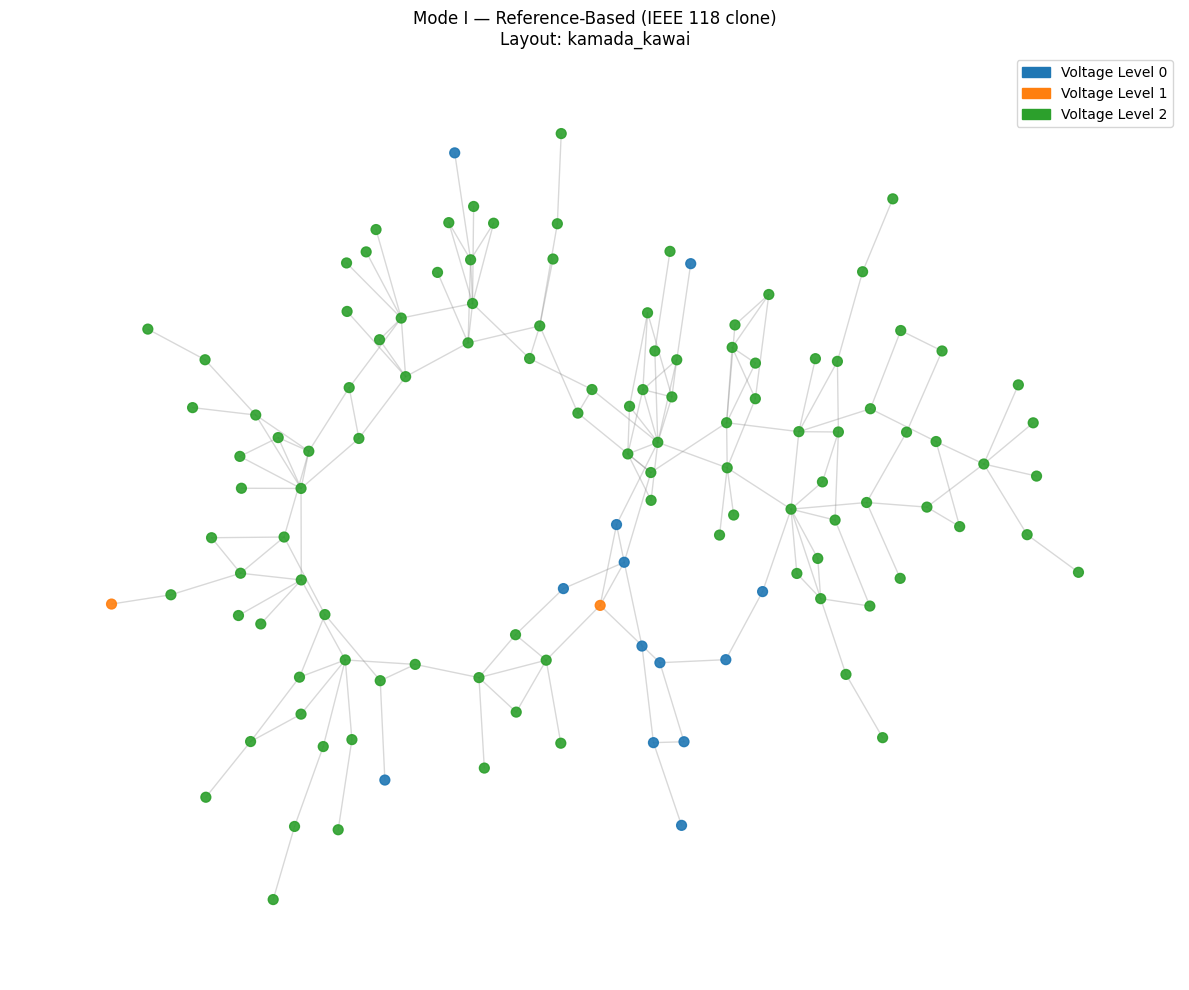

In [4]:
from powergrid_synth import GridVisualizer

vis = GridVisualizer()
vis.plot_grid(grid_ref, title="Mode I — Reference-Based (IEEE 118 clone)")

### Using a custom pandapower network

Instead of a built-in case name, you can pass any pre-loaded `pandapowerNet` via the `reference_net` parameter:

In [5]:
import pandapower.networks as pn

my_net = pn.case300()

grid_300 = synthesize(
    mode="reference",
    reference_net=my_net,
    seed=123,
    output_dir="output/ref_synthesis",
    output_name="case300_clone",
    export_formats=["json"],
)

print(f"Synthesised grid: {grid_300.number_of_nodes()} nodes, {grid_300.number_of_edges()} edges")

Extracting topology parameters...
[1] Loaded reference grid: 300 nodes, 409 edges.
--- Starting Generation for 13 Voltage Levels ---
Generating Level 0...
  -> Level 0 Complete. Nodes: 18, Edges: 15
Generating Level 1...
  -> Level 1 Complete. Nodes: 89, Edges: 93
Generating Level 2...
  -> Level 2 Complete. Nodes: 21, Edges: 16
Generating Level 3...
  -> Level 3 Complete. Nodes: 135, Edges: 146
Generating Level 4...
  -> Level 4 Complete. Nodes: 2, Edges: 0
Generating Level 5...
  -> Level 5 Complete. Nodes: 23, Edges: 15
Generating Level 6...
  -> Level 6 Complete. Nodes: 1, Edges: 0
Generating Level 7...
  -> Level 7 Complete. Nodes: 5, Edges: 0
Generating Level 8...
  -> Level 8 Complete. Nodes: 1, Edges: 0
Generating Level 9...
  -> Level 9 Complete. Nodes: 23, Edges: 0
Generating Level 10...
  -> Level 10 Complete. Nodes: 13, Edges: 9
Generating Level 11...
  -> Level 11 Complete. Nodes: 3, Edges: 0
Generating Level 12...
  -> Level 12 Complete. Nodes: 15, Edges: 0
Generating Tra

## Mode II — Fully Synthetic

Build a grid from scratch by specifying the voltage-level topology and inter-level connections.

Key parameters:
- `level_specs`: list of dicts, one per voltage level, each containing:
  - `n` — target number of nodes
  - `avg_k` — average node degree
  - `diam` — target graph diameter
  - `dist_type` — degree distribution type: `"dgln"` (Double Generalised Log-Normal), `"dpl"` (Double Power-Law), or `"poisson"`
- `connection_specs`: dict mapping `(level_i, level_j)` tuples to connection parameters:
  - `type` — `"k-stars"` or `"simple"`
  - `c`, `gamma` — model parameters

In [6]:
# Define 3 voltage levels: backbone, distribution, local
level_specs = [
    {"n": 50,  "avg_k": 3.5, "diam": 10, "dist_type": "dgln"},   # HV backbone
    {"n": 150, "avg_k": 2.5, "diam": 15, "dist_type": "dpl"},    # MV distribution
    {"n": 300, "avg_k": 2.0, "diam": 20, "dist_type": "poisson"}, # LV local
]

# Define inter-level transformer connections
connection_specs = {
    (0, 1): {"type": "k-stars", "c": 0.174, "gamma": 4.15},
    (1, 2): {"type": "k-stars", "c": 0.15,  "gamma": 4.15},
}

grid_syn = synthesize(
    mode="synthetic",
    level_specs=level_specs,
    connection_specs=connection_specs,
    seed=42,
    output_dir="output/syn_synthesis",
    output_name="synthetic_500",
    export_formats=["json", "xiidm", "psse"],
)

print(f"\nSynthesised grid: {grid_syn.number_of_nodes()} nodes, {grid_syn.number_of_edges()} edges")

Generating Level 0: DGLN distribution (Avg=3.5)
Generating Level 1: DPL distribution (Avg=2.5)
Generating Level 2: POISSON distribution (Avg=2.0)
Generating Transformers 0<->1: k-Stars Model
4.15
Generating Transformers 1<->2: k-Stars Model
4.15
[1] Generated synthetic input parameters for 3 voltage levels.
--- Starting Generation for 3 Voltage Levels ---
Generating Level 0...
  -> Level 0 Complete. Nodes: 56, Edges: 70
Generating Level 1...
  -> Level 1 Complete. Nodes: 208, Edges: 166
Generating Level 2...
  -> Level 2 Complete. Nodes: 352, Edges: 331
Generating Transformer Connections...
  -> Connecting Level 0 <-> Level 1
  -> Connecting Level 1 <-> Level 2
Filtering for Largest Connected Component (LCC)...
  -> Kept 442 nodes (removed 174 isolated nodes)
[2] Topology generated: 442 nodes, 583 edges.
Starting Bus Type Allocation (N=442, M=583)...
  Target Entropy Score (W*): 2.5880, Std Dev: 0.0218
  Iter 0: Best Error = 0.002662
  Converged at iteration 9. Error: 0.000007 < Criter

Calculating layout 'yifan_hu'...


/Users/maosheng/kDrive/a_postdoc/CLC_synthesizer/powergrid_synth/visualization.py:144: RuntimeWarning: divide by zero encountered in divide
  fr = (k**2 / dist_sq[..., np.newaxis]) * delta
/Users/maosheng/kDrive/a_postdoc/CLC_synthesizer/powergrid_synth/visualization.py:144: RuntimeWarning: invalid value encountered in multiply
  fr = (k**2 / dist_sq[..., np.newaxis]) * delta


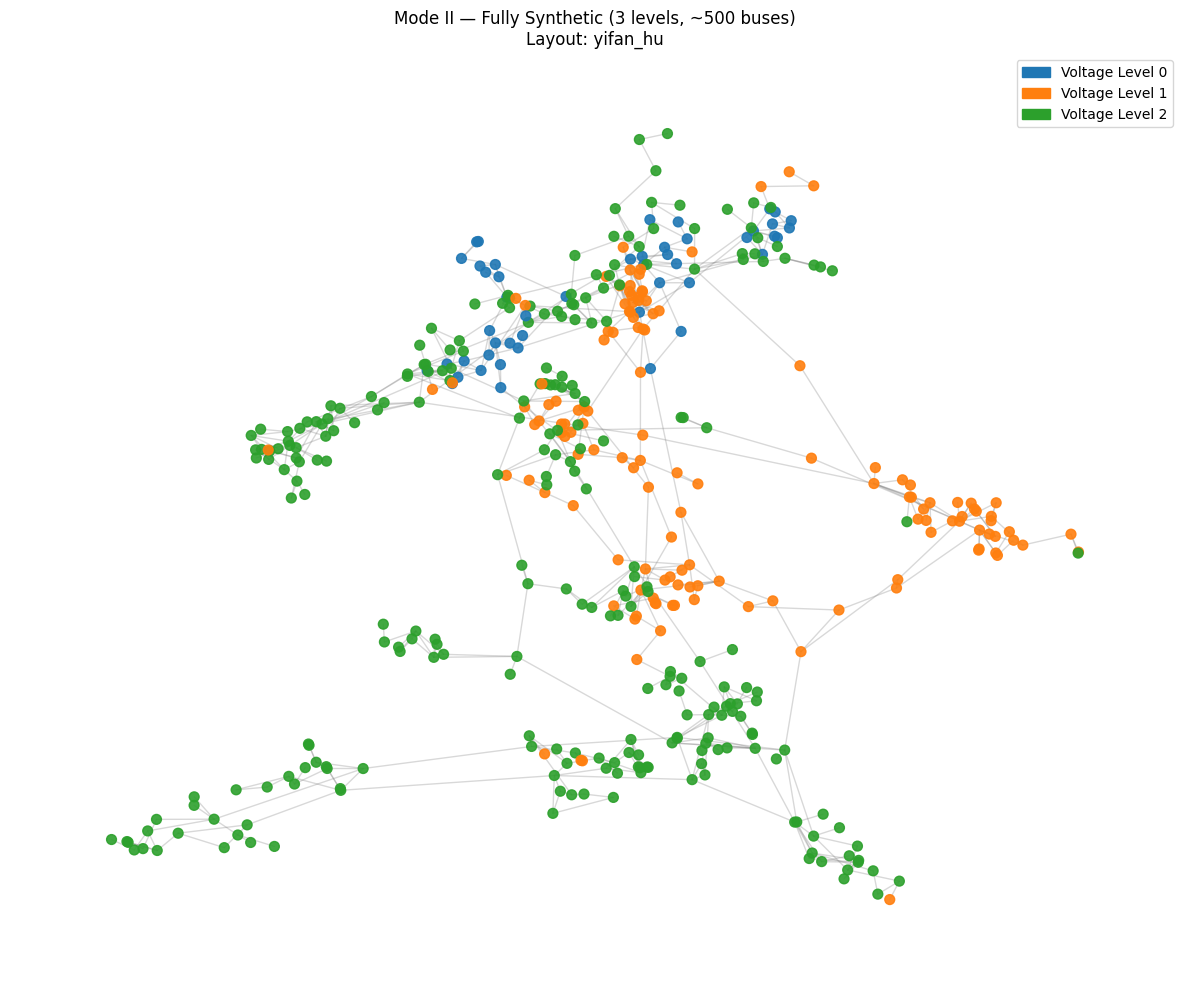

In [7]:
vis.plot_grid(grid_syn, layout="yifan_hu", title="Mode II — Fully Synthetic (3 levels, ~500 buses)")

## Tuning Optional Parameters

The `synthesize()` function exposes all the knobs of the underlying pipeline:

| Parameter | Default | Description |
|-----------|---------|-------------|
| `keep_lcc` | `True` | Keep only the largest connected component after topology generation |
| `entropy_model` | `0` | Bus-type entropy model (0 = standard, 1 = weighted) |
| `bus_type_ratio` | `None` | Custom `[Gen%, Load%, Conn%]` target ratios |
| `ref_sys_id` | `1` | Reference system for statistical tables (0–3) |
| `loading_level` | `"H"` | Load level: `"D"` (deterministic), `"L"` (light), `"M"` (medium), `"H"` (heavy) |
| `refine_topology` | `False` | Allow transmission allocator to add/remove edges for DCPF convergence |
| `base_kv_map` | `None` | Custom `{level_index: kV}` mapping |

### Example: medium loading with custom bus-type ratios

In [8]:
grid_custom = synthesize(
    mode="reference",
    reference_case="case118",
    seed=99,
    loading_level="M",
    bus_type_ratio=[0.30, 0.50, 0.20],  # 30% gen, 50% load, 20% connection
    output_dir="output/custom",
    output_name="ieee118_custom",
    export_formats=["json"],
)

print(f"\nCustom grid: {grid_custom.number_of_nodes()} nodes, {grid_custom.number_of_edges()} edges")

Extracting topology parameters...
[1] Loaded reference grid: 118 nodes, 179 edges.
--- Starting Generation for 3 Voltage Levels ---
Generating Level 0...
  -> Level 0 Complete. Nodes: 13, Edges: 9
Generating Level 1...
  -> Level 1 Complete. Nodes: 2, Edges: 0
Generating Level 2...
  -> Level 2 Complete. Nodes: 116, Edges: 150
Generating Transformer Connections...
  -> Connecting Level 0 <-> Level 1
  -> Connecting Level 0 <-> Level 2
  -> Connecting Level 1 <-> Level 2
Filtering for Largest Connected Component (LCC)...
  -> Kept 118 nodes (removed 13 isolated nodes)
[2] Topology generated: 118 nodes, 170 edges.
Starting Bus Type Allocation (N=118, M=170)...
  Target Entropy Score (W*): 2.6825, Std Dev: 0.0340
  Iter 0: Best Error = 0.003168
  Converged at iteration 6. Error: 0.000001 < Criteria: 0.000034
[3] Bus types assigned: Gen: 35 (30%), Load: 58 (49%), Conn: 25 (21%)
Allocating Capacity for 35 generators.
Total System Capacity Target: 10631.90 MW using Reference System 1
[4] Gen

## Power-Flow Validation

The exported grids can be validated with power-flow solvers from pandapower or pypowsybl.

In [9]:
from powergrid_synth import nx_to_pandapower
import pandapower as pp

# Convert to pandapower and run DC power flow
net = nx_to_pandapower(grid_ref)
pp.runpp(net)

print("AC power-flow results (first 10 buses):")
print(net.res_bus.head(10))

DC power-flow results (first 10 buses):
      vm_pu  va_degree         p_mw     q_mvar
0  0.997322  -6.222975    56.335915   0.000000
1  0.991230  -4.279591     0.000000   0.000000
2  0.980314  -6.887049     0.000000   0.000000
3  0.973481 -10.079917     9.358185   0.000000
4  0.982129 -13.812748   109.951167   0.000000
5  0.975794 -13.077277    47.697075   0.000000
6  1.000000   4.888344 -1027.399869 -12.934121
7  0.983676  -7.861924   372.593024   0.000000
8  0.988089  -6.351151     0.000000   0.000000
9  0.989249  -3.365704     0.000000   0.000000


## Supported Export Formats

| Via | Formats | Format Key |
|-----|---------|------------|
| **pandapower** | JSON, Excel, SQLite, Pickle | `"json"`, `"excel"`, `"sqlite"`, `"pickle"` |
| **pypowsybl** | CGMES, XIIDM, MATPOWER, PSS/E | `"cgmes"`, `"xiidm"`, `"matpower"`, `"psse"` |

Pass any combination to `export_formats`. All output files are written to the specified `output_dir`.